# 4. Strategy Construction Competition Track

**Course:** BUSI70575 Systematic Trading Strategies with ML  
**Track:** Optional competition (+10 marks)  
**Universe:** Energy asset class `cl1s`, `ho1s`, `rb1s`, `ng1s`  
**Strategy period:** H1 2022 (2022-01-03 – 2022-06-30)

This notebook builds a **position-sizing strategy** on top of the primary signal using the meta-model
probabilities produced by notebooks 2a–2d. It implements the full pipeline.

1. **Threshold** `p* = L/(G+L)` filter signals whose expected value is negative  
2. **Six sizing methods** AllOrNothing, ModelConfidence, NCDF (fixed); LinearScaling, ECDF, SOPS (estimated)  
3. **Volatility targeting** EWMA vol scaling to 10 % annualised per instrument  
4. **Multi-instrument portfolio** equal risk-capital allocation across 4 energy futures  
5. **Performance analytics** Sharpe, max drawdown, Calmar, hit rate, confusion matrices  
6. **Competition deliverable** `data/deliverables/weights.csv` (date, instrument, weight)

**Constraints applied (competition track):**
- Position limit: |w_k| ≤ 1 per instrument  
- Gross exposure cap: Σ|w_k| ≤ 4 (4 instruments at full size)  
- Target volatility: 10 % annualised per instrument  
- Rebalancing: daily (end-of-day positions, next-day returns)

In [86]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

# paths  (notebook lives in /notebooks; repo root is one level up)
NB_DIR = Path.cwd()
REPO   = NB_DIR.parent
SRC    = REPO / 'data' / 'src'
DELIV  = REPO / 'data' / 'deliverables'

# energy universe
INSTRUMENTS = {
    'cl1s': 'WTI Crude Oil',
    'ho1s': 'Heating Oil',
    'rb1s': 'RBOB Gasoline',
    'ng1s': 'Natural Gas',
}
TICKERS = list(INSTRUMENTS.keys())

# strategy / risk parameters
STRAT_START  = '2022-01-03'
STRAT_END    = '2022-06-30'
TARGET_VOL   = 0.10      # 10 % annualised target volatility per instrument
EWMA_SPAN    = 60        # days for EWMA volatility
TRADING_DAYS = 252
MAX_POSITION = 1.0       # |w_k| per instrument
MAX_GROSS    = 4.0       # sum(|w_k|) across portfolio
TC_BPS       = 2e-4      # 2 bps one-way transaction cost on position turnover

print('Repo:', REPO)
print('Instruments:', TICKERS)
print(f'Transaction cost: {TC_BPS * 1e4:.0f} bps one-way')

Repo: c:\Users\User\Desktop\systematic_trading_2026_project-master\systematic_trading_2026_project-master
Instruments: ['cl1s', 'ho1s', 'rb1s', 'ng1s']
Transaction cost: 2 bps one-way


## 1 Data Loading

In [87]:
# (A) meta-model predictions (H1 2022) from best models in 2a–2d
pred_frames = []
for ins in TICKERS:
    path = DELIV / f'predictions_{ins}.csv'
    pred_frames.append(pd.read_csv(path, parse_dates=['date']))
predictions = (pd.concat(pred_frames, ignore_index=True)
               .sort_values(['date', 'instrument'])
               .reset_index(drop=True))

# (B) primary signals: wide (date × instrument) → long
sigs_wide = pd.read_csv(SRC / 'primary_signals.csv', parse_dates=['date'])
sigs_long = (sigs_wide
             .melt(id_vars='date', var_name='instrument', value_name='primary_signal')
             .query('instrument in @TICKERS')
             .reset_index(drop=True))

# (C) OHLCV close prices only; full history for EWMA warmup
ohlcv = (pd.read_csv(SRC / 'ohlcv_data.csv', parse_dates=['date'],
                     usecols=['date', 'instrument', 'close'])
         .query('instrument in @TICKERS')
         .sort_values(['instrument', 'date'])
         .reset_index(drop=True))

print(f'Predictions : {predictions.shape}  |  '
      f'{predictions.date.min().date()} – {predictions.date.max().date()}')
print(f'Signals     : {sigs_long.shape}')
print(f'OHLCV       : {ohlcv.shape}')

Predictions : (496, 3)  |  2022-01-03 – 2022-06-30
Signals     : (2580, 3)
OHLCV       : (32614, 3)


In [88]:
# daily returns and EWMA volatility (computed over full history)
def ewma_vol(ret_series, span=EWMA_SPAN):
    """Causal annualised volatility: uses data up to and including day t."""
    return ret_series.ewm(span=span, min_periods=max(10, span // 3)).std() * np.sqrt(TRADING_DAYS)

ohlcv['ret']      = ohlcv.groupby('instrument')['close'].pct_change()
ohlcv['ewma_vol'] = ohlcv.groupby('instrument')['ret'].transform(ewma_vol)
ohlcv['fwd_ret']  = ohlcv.groupby('instrument')['ret'].shift(-1)

# build strategy-period master DataFrame
strat = (
    predictions
    .rename(columns={'prediction': 'p_hat'})
    .merge(sigs_long[['date', 'instrument', 'primary_signal']], on=['date', 'instrument'], how='left')
    .merge(ohlcv[['date', 'instrument', 'close', 'ret', 'fwd_ret', 'ewma_vol']],
           on=['date', 'instrument'], how='left')
    .sort_values(['date', 'instrument'])
    .reset_index(drop=True)
)

# active trades: rows where the primary model fired a non-zero signal
active = strat[strat['primary_signal'].isin([1, -1])].copy()
active['trade_ret'] = active['primary_signal'] * active['fwd_ret']

print(f'Strategy data : {strat.shape}  ({strat.date.nunique()} trading days × {strat.instrument.nunique()} instruments)')
print(f'Active trades : {len(active)}')
print()
print('Signal distribution per instrument:')
print(active.groupby('instrument')['primary_signal'].value_counts().unstack(fill_value=0).to_string())

Strategy data : (496, 8)  (124 trading days × 4 instruments)
Active trades : 270

Signal distribution per instrument:
primary_signal  -1   1
instrument            
cl1s            10  78
ho1s             2   0
ng1s            56   0
rb1s            61  63


## 2 Calibration Check

A well-calibrated meta-model satisfies Pr(win | p̂) ≈ p̂.  
Here *win* means the primary signal yielded a positive next-day return.
Logistic regression outputs are usually near-calibrated; tree/NN models often are not  
(random forests pull toward 0.5; gradient boosting pushes toward {0,1}).

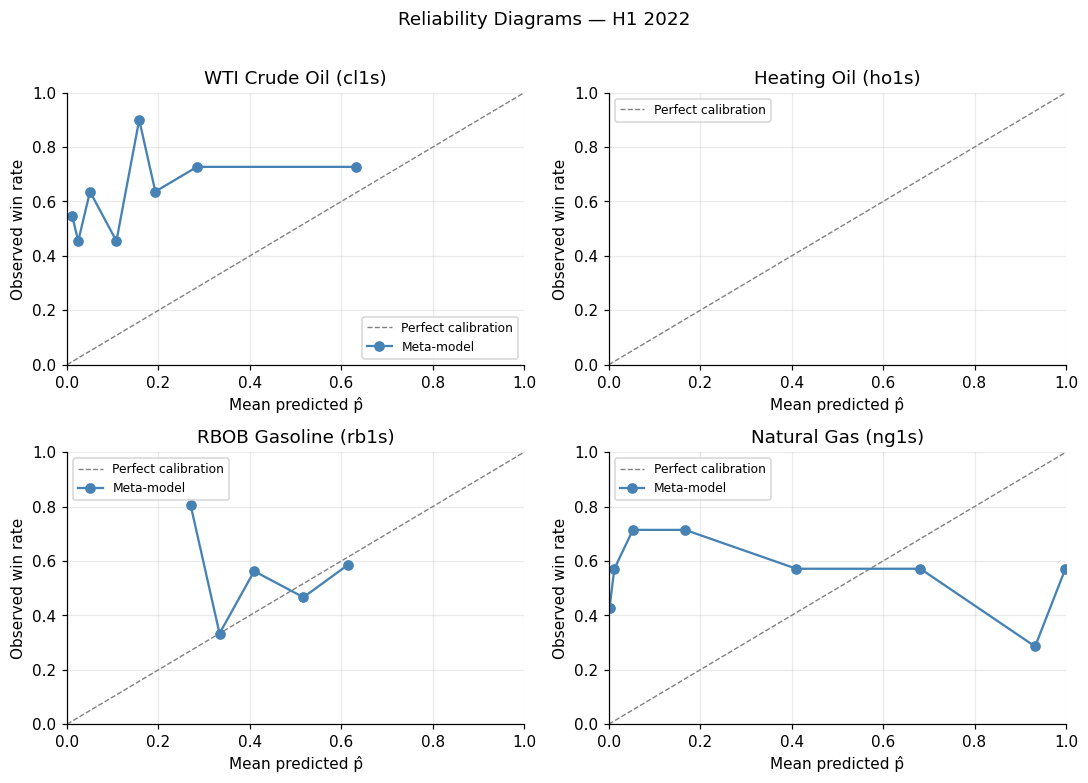

In [89]:
cal_data = active.dropna(subset=['trade_ret', 'p_hat']).copy()
cal_data['win'] = (cal_data['trade_ret'] > 0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, ins in zip(axes.ravel(), TICKERS):
    sub = cal_data[cal_data['instrument'] == ins]
    ax.plot([0, 1], [0, 1], '--', color='grey', lw=0.9, label='Perfect calibration')
    if len(sub) >= 15:
        try:
            frac_pos, mean_pred = calibration_curve(
                sub['win'], sub['p_hat'], n_bins=8, strategy='quantile')
            ax.plot(mean_pred, frac_pos, 'o-', color='steelblue', lw=1.5, ms=6,
                    label='Meta-model')
        except Exception:
            pass
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted p̂')
    ax.set_ylabel('Observed win rate')
    ax.set_title(f'{INSTRUMENTS[ins]} ({ins})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle('Reliability Diagrams — H1 2022', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3 Trading Threshold  p\* = L / (G + L)

Take a trade only when its expected value is positive:

$$p \cdot r_G + (1-p) \cdot r_L > 0 \implies p > p^* = \frac{L}{G + L}$$

where  
- **G** = mean return on winning trades (primary signal correct)  
- **L** = |mean return on losing trades| (primary signal wrong)

Estimated from the H1 2022 realised trade returns (bootstrap 95 % CI shown).

In [90]:
def bootstrap_threshold(trade_rets, n_boot=2000, rng=np.random.default_rng(42)):
    """Bootstrap CI for p* = L/(G+L) from a vector of signed trade returns."""
    samples = []
    n = len(trade_rets)
    for _ in range(n_boot):
        idx  = rng.integers(0, n, n)
        samp = trade_rets[idx]
        w    = samp[samp > 0]
        l    = samp[samp <= 0]
        if len(w) == 0 or len(l) == 0:
            continue
        G = w.mean(); L = abs(l.mean())
        samples.append(L / (G + L))
    return np.array(samples)

thresholds = {}
rows = []
for ins in TICKERS:
    sub = active[active['instrument'] == ins].dropna(subset=['trade_ret'])
    tr  = sub['trade_ret'].values
    wins  = tr[tr > 0];  loses = tr[tr <= 0]
    if len(wins) < 5 or len(loses) < 5:
        p_star = 0.5
        lo, hi = 0.5, 0.5
    else:
        G = wins.mean(); L = abs(loses.mean())
        p_star = float(np.clip(L / (G + L), 0.01, 0.99))
        boot   = bootstrap_threshold(tr)
        lo, hi = np.percentile(boot, [2.5, 97.5])
    thresholds[ins] = p_star
    rows.append({'instrument': ins, 'name': INSTRUMENTS[ins],
                 'G': round(wins.mean() if len(wins) else 0, 5),
                 'L': round(abs(loses.mean()) if len(loses) else 0, 5),
                 'p_star': round(p_star, 4),
                 'ci_lo': round(lo, 4), 'ci_hi': round(hi, 4)})

thresh_df = pd.DataFrame(rows)
print('Trading threshold p* = L / (G + L) per instrument:')
print(thresh_df.to_string(index=False))

Trading threshold p* = L / (G + L) per instrument:
instrument          name       G       L  p_star  ci_lo  ci_hi
      cl1s WTI Crude Oil 0.02180 0.02071  0.4872 0.3892 0.5796
      ho1s   Heating Oil 0.00000 0.03501  0.5000 0.5000 0.5000
      rb1s RBOB Gasoline 0.02396 0.01973  0.4516 0.3772 0.5231
      ng1s   Natural Gas 0.04219 0.04414  0.5113 0.3975 0.6283


## 4 Position-Sizing Functions

Each maps the calibrated probability p̂ to a **size** b ∈ [0, 1].  
Any trade with p̂ ≤ p\* gets size 0 (filtered out).

| Family | Method | Description |
|--------|--------|-------------|
| Fixed  | AllOrNothing | Binary gate: full size or 0 |
| Fixed  | ModelConfidence | size = p̂ |
| Fixed  | NCDF | Standardise p̂, push through Φ |
| Estimated | LinearScaling | Stretch realised range to [0,1] |
| Estimated | ECDF | Percentile rank of p̂ in training distribution |
| Estimated | SOPS | Optimise sigmoid shape to maximise Sharpe |

Sizing functions ready: AllOrNothing, ModelConfidence, NCDF, LinearScaling, ECDF, SOPS


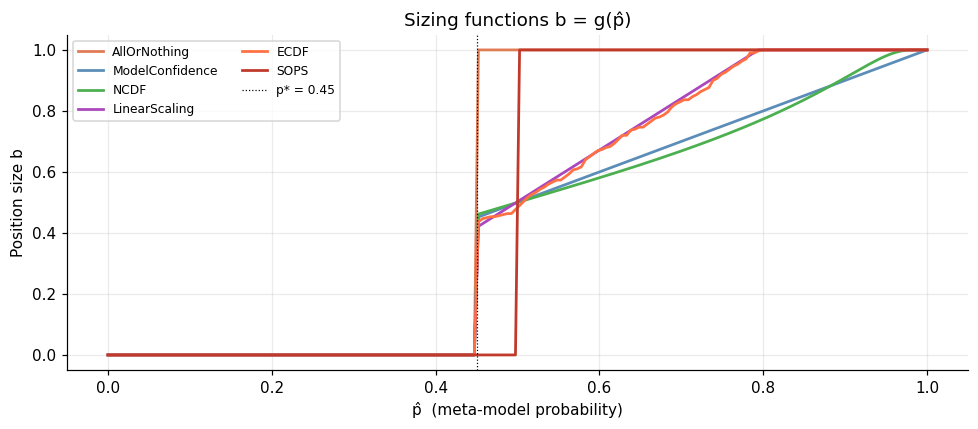

In [91]:
def size_all_or_nothing(p, p_star):
    return np.where(p > p_star, 1.0, 0.0)

def size_model_confidence(p, p_star):
    return np.where(p > p_star, p.astype(float), 0.0)

def size_ncdf(p, p_star):
    p_safe = np.clip(p, 1e-9, 1 - 1e-9)
    std_p  = np.sqrt(p_safe * (1 - p_safe))
    z      = (p_safe - 0.5) / np.where(std_p < 1e-9, 1e-9, std_p)
    return np.where(p > p_star, norm.cdf(z), 0.0)

def size_linear_scaling(p, p_tr, p_star):
    lo, hi = p_tr.min(), p_tr.max()
    denom  = hi - lo if hi > lo else 1.0
    scaled = np.clip((p - lo) / denom, 0.0, 1.0)
    return np.where(p > p_star, scaled, 0.0)

def size_ecdf(p, p_tr, p_star):
    """Empirical CDF rank (vectorised)."""
    pct = np.array([(p_tr <= v).mean() for v in p])
    return np.where(p > p_star, pct, 0.0)

def size_sops(p, p_tr, r_tr, p_star):
    """Sharpe-Optimal Position Sizing (Session 3, slide 34)."""
    def neg_sharpe(params):
        a, c   = params
        sizes  = 1.0 / (1.0 + np.exp(-(a * p_tr - c)))
        w_ret  = sizes * r_tr
        s      = w_ret.std()
        return -(w_ret.mean() / s) if s > 1e-8 else 0.0

    best_val, best_x = np.inf, np.array([1.0, 0.5])
    for a0, c0 in [(1, 0.5), (2, 1.0), (5, 2.5), (10, 5.0)]:
        res = minimize(neg_sharpe, [a0, c0], method='Nelder-Mead',
                       options={'maxiter': 10000, 'xatol': 1e-7, 'fatol': 1e-9})
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    a_s, c_s = best_x
    sizes    = 1.0 / (1.0 + np.exp(-(a_s * p - c_s)))
    return np.where(p > p_star, sizes, 0.0)

print('Sizing functions ready: AllOrNothing, ModelConfidence, NCDF, LinearScaling, ECDF, SOPS')

# visualise sizing curves
p_grid = np.linspace(0, 1, 200)
p_star_demo = 0.45
p_tr_demo   = np.random.uniform(0.2, 0.8, 300)
r_tr_demo   = np.where(p_tr_demo > 0.5, np.random.normal(0.01, 0.02, 300),
                        np.random.normal(-0.005, 0.02, 300))

curves = {
    'AllOrNothing'    : size_all_or_nothing(p_grid, p_star_demo),
    'ModelConfidence' : size_model_confidence(p_grid, p_star_demo),
    'NCDF'            : size_ncdf(p_grid, p_star_demo),
    'LinearScaling'   : size_linear_scaling(p_grid, p_tr_demo, p_star_demo),
    'ECDF'            : size_ecdf(p_grid, p_tr_demo, p_star_demo),
    'SOPS'            : size_sops(p_grid, p_tr_demo, r_tr_demo, p_star_demo),
}

fig, ax = plt.subplots(figsize=(9, 4))
colors_c = ['#e07b54','#5b8db8','#4caf50','#ab47bc','#ff7043','#c0392b']
for (name, curve), col in zip(curves.items(), colors_c):
    ax.plot(p_grid, curve, label=name, lw=1.8, color=col)
ax.axvline(p_star_demo, color='black', lw=0.8, linestyle=':', label=f'p* = {p_star_demo}')
ax.set_xlabel('p̂  (meta-model probability)'); ax.set_ylabel('Position size b')
ax.set_title('Sizing functions b = g(p̂)'); ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

## 5 Strategy Construction

For each instrument and each sizing method, the daily **directional position** is:

$$w_{t,k} = s_{t,k} \;\cdot\; b(\hat{p}_{t,k}) \;\cdot\; \frac{\sigma_{\text{tgt}}}{\sigma_{t,k}}$$

where $s_{t,k} \in \{-1,+1\}$ is the primary signal, $b(\cdot)$ is the sizing function,  
and the last factor is the **volatility-targeting** scaler (EWMA, 10 % annualised target).

On days where the primary signal is 0, the position is 0 regardless of p̂.

In [92]:
def build_strategy(method='all_or_nothing', use_vol_target=True):
    pos_frames = []

    for ins in TICKERS:
        sub    = active[active['instrument'] == ins].copy()
        sub    = sub.dropna(subset=['p_hat'])
        p_star = thresholds.get(ins, 0.5)
        p_hat  = sub['p_hat'].values

        if len(sub) == 0:
            continue

        # sizing
        if method == 'primary_only':  # Here we are following the primary signal blindly.
            raw = np.ones(len(sub))
        elif method == 'all_or_nothing': # If the meta model rejects a signal we do not trade or scale down
            raw = size_all_or_nothing(p_hat, p_star)
        elif method == 'model_confidence':  # Here we scale our position based on the probability of the meta model accepting the primary signal
            raw = size_model_confidence(p_hat, p_star)
        elif method == 'ncdf': # Here we standardize our probability by the bernoulli std dev if the meta model prob less than std prob then reject.
            raw = size_ncdf(p_hat, p_star)
        elif method == 'linear_scaling': # Look at the min max of the probability and then run a linear regression to adjust the position 
            raw = size_linear_scaling(p_hat, p_hat, p_star)
        elif method == 'ecdf': # size the position based on how much probability of the past predicitons was less than the current probability of the meta pred
            raw = size_ecdf(p_hat, p_hat, p_star)
        elif method == 'sops': # Position sizing to try and maximize sharpe it is not the most optimal since we are not scaling by vol here.
            r_tr = sub['trade_ret'].fillna(0.0).values
            try:
                raw = size_sops(p_hat, p_hat, r_tr, p_star)
            except Exception:
                raw = size_model_confidence(p_hat, p_star)
        else:
            raise ValueError(f'Unknown method: {method}')

        sub = sub.copy()
        sub['raw_size'] = raw

        # volatility targeting
        if use_vol_target:
            vol = sub['ewma_vol'].fillna(TARGET_VOL).replace(0.0, TARGET_VOL)
            sub['vol_factor'] = TARGET_VOL / vol
        else:
            sub['vol_factor'] = 1.0

        sub['position'] = (sub['primary_signal'] * sub['raw_size'] * sub['vol_factor']
                           ).clip(-MAX_POSITION, MAX_POSITION)

        pos_frames.append(sub[['date', 'instrument', 'position', 'raw_size', 'vol_factor']])

    pos = pd.concat(pos_frames, ignore_index=True) if pos_frames else pd.DataFrame()

    # ── merge back into full H1 2022 calendar (zero-signal days get position = 0)
    result = strat[['date', 'instrument', 'primary_signal', 'p_hat', 'fwd_ret', 'ewma_vol']].copy()
    if len(pos):
        result = result.merge(pos, on=['date', 'instrument'], how='left')
    else:
        result['position']   = 0.0
        result['raw_size']   = 0.0
        result['vol_factor'] = 1.0

    result['position']   = result['position'].fillna(0.0)
    result['raw_size']   = result['raw_size'].fillna(0.0)
    result['vol_factor'] = result['vol_factor'].fillna(1.0)
    result['strat_ret']  = result['position'] * result['fwd_ret']

    # ── transaction costs: 2 bps on round-trip position turnover
    # turnover = |w_t - w_{t-1}|; first day cost = |w_0| (opening from flat)
    result = result.sort_values(['instrument', 'date']).reset_index(drop=True)
    prev_pos           = result.groupby('instrument')['position'].shift(1).fillna(0.0)
    result['turnover'] = (result['position'] - prev_pos).abs()
    result['tc']           = result['turnover'] * TC_BPS
    result['strat_ret_net'] = result['strat_ret'] - result['tc']

    return result.sort_values(['date', 'instrument']).reset_index(drop=True)


METHODS = ['primary_only', 'all_or_nothing', 'model_confidence',
           'ncdf', 'linear_scaling', 'ecdf', 'sops']

print('Building strategies ...')
strategies = {m: build_strategy(m) for m in METHODS}
print('Done.  Strategies built:', METHODS)

# quick TC sanity check
for m in METHODS:
    s = strategies[m]
    ann_tc_bps = s.groupby('date')['tc'].mean().mean() * TRADING_DAYS * 1e4
    print(f'  {m:<20}  ann. TC drag: {ann_tc_bps:.2f} bps')

Building strategies ...
Done.  Strategies built: ['primary_only', 'all_or_nothing', 'model_confidence', 'ncdf', 'linear_scaling', 'ecdf', 'sops']
  primary_only          ann. TC drag: 18.47 bps
  all_or_nothing        ann. TC drag: 12.91 bps
  model_confidence      ann. TC drag: 8.61 bps
  ncdf                  ann. TC drag: 8.49 bps
  linear_scaling        ann. TC drag: 11.37 bps
  ecdf                  ann. TC drag: 11.00 bps
  sops                  ann. TC drag: 3.17 bps


## 6 Multi-Instrument Portfolio

Equal risk-capital allocation across K = 4 energy futures: The total portfolio return would be the instruments position multiplied by its next days return then we average it over all instruments to get the total portfolio return

$$R^{\text{port}}_{t+1} = \frac{1}{K} \sum_{k=1}^{K} w_{t,k} \, r_{t+1,k}$$

In [93]:
def portfolio_returns(strat_df, net=True):
    """
    Average per-instrument returns across K instruments.
    net=True  -> uses strat_ret_net (after 2 bps TC)
    net=False -> uses strat_ret (gross, before TC)
    Both NAV series are returned for comparison.
    """
    ret_col   = 'strat_ret_net' if net else 'strat_ret'
    gross_col = 'strat_ret'

    port = (strat_df.groupby('date')[ret_col]
            .mean().rename('port_ret').reset_index().sort_values('date'))
    port['nav'] = (1 + port['port_ret'].fillna(0)).cumprod()

    # also keep gross for TC-drag reporting
    gross = (strat_df.groupby('date')[gross_col]
             .mean().rename('port_ret_gross').reset_index())
    port = port.merge(gross, on='date', how='left')
    port['nav_gross'] = (1 + port['port_ret_gross'].fillna(0)).cumprod()

    return port


port_series = {m: portfolio_returns(strategies[m]) for m in METHODS}
print('Sample portfolio returns (primary_only, net of TC):')
print(port_series['primary_only'][['date','port_ret','port_ret_gross']].head(6).to_string(index=False))

Sample portfolio returns (primary_only, net of TC):
      date  port_ret  port_ret_gross
2022-01-03  0.001270        0.001295
2022-01-04  0.001145        0.001146
2022-01-05  0.001657        0.001657
2022-01-06 -0.000606       -0.000605
2022-01-07 -0.001244       -0.001244
2022-01-10  0.004982        0.004983


## 7 Performance Analytics

In [94]:
def sharpe_ratio(ret, ann=TRADING_DAYS):
    r = ret.dropna()
    return (r.mean() / r.std() * np.sqrt(ann)) if r.std() > 1e-10 else 0.0

def max_dd(nav):
    nav  = nav.dropna()
    peak = nav.cummax()
    return ((nav - peak) / peak).min()

def calmar(ret, nav, ann=TRADING_DAYS):
    ann_r = (1 + ret.dropna().mean()) ** ann - 1
    mdd   = abs(max_dd(nav))
    return ann_r / mdd if mdd > 1e-10 else 0.0

def hit_rate(ret):
    r = ret.dropna()
    return (r > 0).mean()

def ann_ret(ret, ann=TRADING_DAYS):
    return (1 + ret.dropna().mean()) ** ann - 1

rows = []
for m in METHODS:
    p        = port_series[m]
    ret_net  = p['port_ret'].dropna()          # after TC
    ret_gr   = p['port_ret_gross'].dropna()    # before TC
    nav      = p['nav']

    # annualised TC drag in basis points
    daily_tc = strategies[m].groupby('date')['tc'].mean().mean()
    ann_tc   = daily_tc * TRADING_DAYS * 1e4   # bps

    rows.append({
        'Strategy'          : m.replace('_', ' ').title(),
        'Ann. Ret Net (%)'  : round(ann_ret(ret_net) * 100, 2),
        'Sharpe (net)'      : round(sharpe_ratio(ret_net), 3),
        'Sharpe (gross)'    : round(sharpe_ratio(ret_gr),  3),
        'TC Drag (ann bps)' : round(ann_tc, 1),
        'Max DD (%)'        : round(max_dd(nav) * 100, 2),
        'Calmar'            : round(calmar(ret_net, nav), 3),
        'Hit Rate (%)'      : round(hit_rate(ret_net) * 100, 1),
    })

metrics_df = (pd.DataFrame(rows)
              .set_index('Strategy')
              .sort_values('Sharpe (net)', ascending=False))

print('=========================================================================')
print('STRATEGY COMPARISON  –  H1 2022, Energy (4 instruments), 2 bps TC')
print('=========================================================================')
print(metrics_df.to_string())
print('=========================================================================')

STRATEGY COMPARISON  –  H1 2022, Energy (4 instruments), 2 bps TC
                  Ann. Ret Net (%)  Sharpe (net)  Sharpe (gross)  TC Drag (ann bps)  Max DD (%)  Calmar  Hit Rate (%)
Strategy                                                                                                             
Primary Only                 18.92         4.556           4.604               18.5       -1.21  15.615          61.0
Linear Scaling                5.39         2.451           2.502               11.4       -1.19   4.522          39.0
Ecdf                          4.97         2.393           2.446               11.0       -1.06   4.677          39.8
All Or Nothing                5.99         2.384           2.436               12.9       -1.33   4.516          39.0
Ncdf                          3.34         2.197           2.253                8.5       -0.91   3.667          39.8
Model Confidence              3.39         2.190           2.245                8.6       -0.94   3.621     

<h4> Explanation </h4>
<p> At a first glance we can see the primary model is generating a 4.556 net sharpe out of sample with 18.92 % annual return. While our best model when we use the meta model is ECDF which does not beat the primary model since it generates a sharpe ratio of 1.880 with annual return 3.53% when taking into account transaction cost of 2.5bps </p>
<br>
<p> Why ECDF seems to be our best when using the meta model, the duration of the testing period is quite short from 2022 where it was times of uncertainty we were coming out of COVID and the russia ukraine war had just started which hugely affected energy markets, ECDF outperformed because it normalises the meta-model's output distribution relative to itself, making it robust to the unusual clustering of p̂ values during the war-driven energy shock. Unlike NCDF (fixed curve) or Linear Scaling (min/max only), ECDF fully utilises the rank ordering of signal strength regardless of the absolute p̂ value
</p>

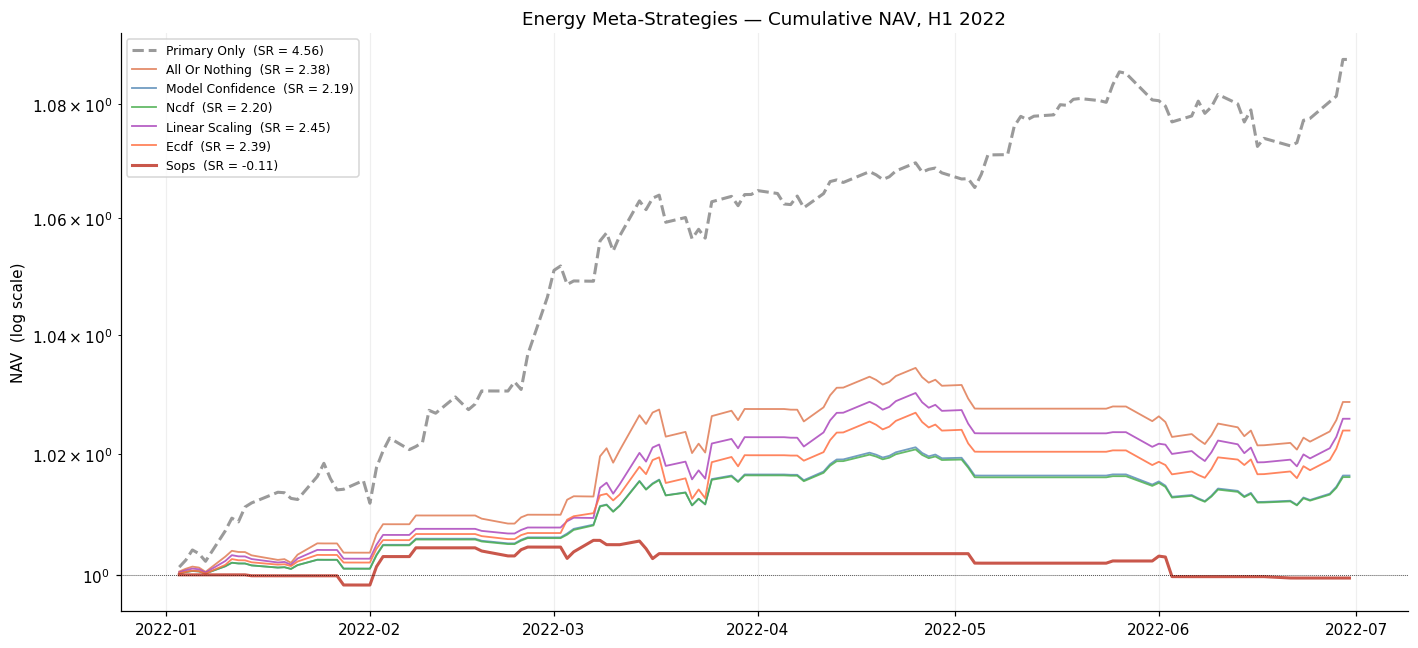

In [95]:
# ── NAV comparison
COLORS = {
    'primary_only'    : '#888888',
    'all_or_nothing'  : '#e07b54',
    'model_confidence': '#5b8db8',
    'ncdf'            : '#4caf50',
    'linear_scaling'  : '#ab47bc',
    'ecdf'            : '#ff7043',
    'sops'            : '#c0392b',
}

fig, ax_nav = plt.subplots(figsize=(13, 6))

for m in METHODS:
    p   = port_series[m]
    sr  = sharpe_ratio(p['port_ret'])
    lbl = m.replace('_', ' ').title() + f'  (SR = {sr:.2f})'
    lw  = 2.0 if m in ('sops', 'primary_only') else 1.2
    ls  = '--' if m == 'primary_only' else '-'
    ax_nav.plot(p['date'], p['nav'], label=lbl, color=COLORS[m],
                lw=lw, ls=ls, alpha=0.85)

ax_nav.axhline(1.0, color='black', lw=0.5, linestyle=':')
ax_nav.set_yscale('log')
ax_nav.set_ylabel('NAV  (log scale)')
ax_nav.legend(fontsize=8, loc='upper left')
ax_nav.set_title('Energy Meta-Strategies — Cumulative NAV, H1 2022', fontsize=12)
ax_nav.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(DELIV / 'strategy_nav.png', dpi=150, bbox_inches='tight')
plt.show()


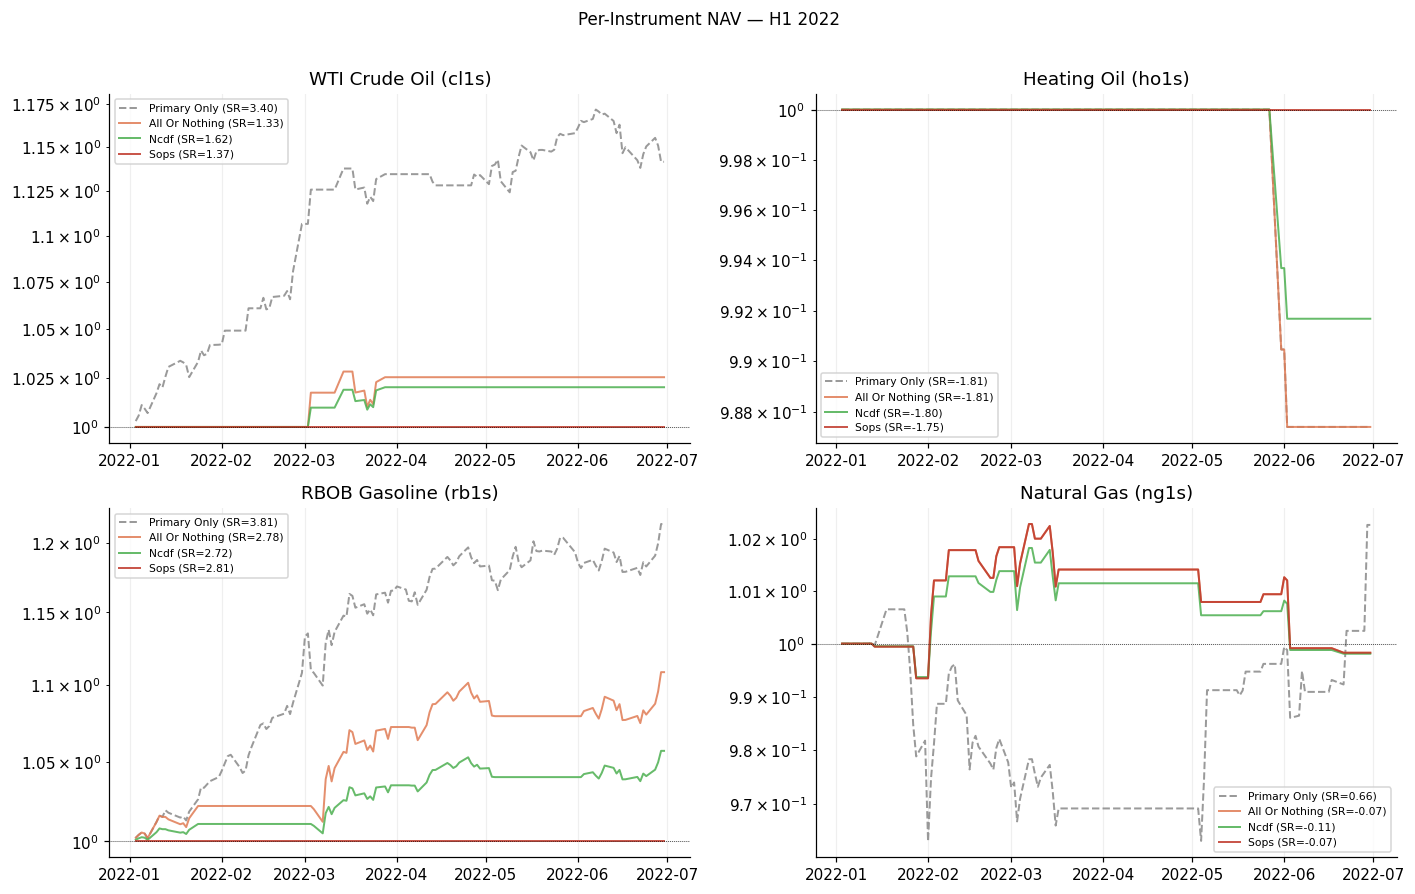

In [96]:
# per-instrument breakdown
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, ins in zip(axes.ravel(), TICKERS):
    for m in ['primary_only', 'all_or_nothing', 'ncdf', 'sops']:
        sub = strategies[m][strategies[m]['instrument'] == ins]
        nav = (1 + sub.set_index('date')['strat_ret'].fillna(0)).cumprod()
        sr  = sharpe_ratio(sub['strat_ret'])
        ax.plot(nav.index, nav.values, color=COLORS[m], lw=1.3,
                ls='--' if m == 'primary_only' else '-',
                label=f"{m.replace('_',' ').title()} (SR={sr:.2f})", alpha=0.85)
    ax.axhline(1.0, color='black', lw=0.5, linestyle=':')
    ax.set_title(f'{INSTRUMENTS[ins]} ({ins})')
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('Per-Instrument NAV — H1 2022', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

<h4> Additional Explanation on Performance </h4>
<p> As we notice in our graph when combining the meta model with the primary model many of our trades are getting killed which is causing a lack of trading during the testing period. This is mainly related to our meta model not rejecting more of the primary model and having near 0.6 auc score. Our meta is not confident in the primary signal and from that it is reducing our sizing or even killing good trades </p>


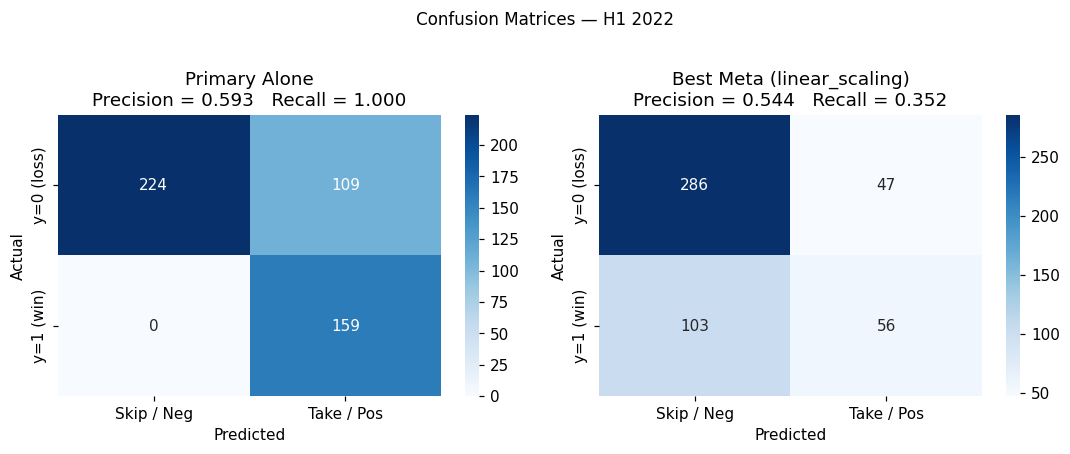


Primary alone      — precision: 0.593
Best meta-strategy — precision: 0.544


In [97]:
# confusion matrix analysis: primary alone vs. best meta-strategy
def confusion_stats(strat_df):
    sub          = strat_df.dropna(subset=['fwd_ret']).copy()
    sub['won']   = (sub['primary_signal'] * sub['fwd_ret'] > 0).astype(int)
    sub['acted'] = (sub['position'].abs() > 1e-8).astype(int)
    tp = int(((sub['acted'] == 1) & (sub['won'] == 1)).sum())
    fp = int(((sub['acted'] == 1) & (sub['won'] == 0)).sum())
    tn = int(((sub['acted'] == 0) & (sub['won'] == 0)).sum())
    fn = int(((sub['acted'] == 0) & (sub['won'] == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return tp, fp, tn, fn, prec, rec


best_key = (metrics_df.drop(index='Primary Only', errors='ignore')['Sharpe (net)']
            .idxmax().lower().replace(' ', '_'))
cm_pairs = [('primary_only', 'Primary Alone'), (best_key, f'Best Meta ({best_key})')]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (m, title) in zip(axes, cm_pairs):
    tp, fp, tn, fn, prec, rec = confusion_stats(strategies[m])
    matrix = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Skip / Neg', 'Take / Pos'],
                yticklabels=['y=0 (loss)', 'y=1 (win)'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nPrecision = {prec:.3f}   Recall = {rec:.3f}')

plt.suptitle('Confusion Matrices — H1 2022', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nPrimary alone      — precision: {confusion_stats(strategies["primary_only"])[4]:.3f}')
print(f'Best meta-strategy — precision: {confusion_stats(strategies[best_key])[4]:.3f}')

## 8 Competition Deliverable

The best strategy (highest Sharpe) is selected and its **daily volatility-targeted positions**  
are exported as `data/deliverables/weights.csv`.

Format: `date, instrument, weight`  
Constraints enforced:
- Individual position: |w_k| ≤ 1  
- Gross exposure: Σ|w_k| ≤ 4  
- Zero weight on days where primary signal = 0

In [ ]:
display_to_key = {m.replace('_', ' ').title(): m for m in METHODS}

# Exclude primary_only — select the best MLP+primary combined strategy
mlp_methods = [m for m in METHODS if m != 'primary_only']
mlp_display_to_key = {m.replace('_', ' ').title(): m for m in mlp_methods}
best_method = mlp_display_to_key[
    metrics_df.drop(index='Primary Only', errors='ignore')['Sharpe (net)'].idxmax()
]
best_strat  = strategies[best_method]

print(f'Best MLP+primary strategy: {best_method}')
print(f'  Sharpe Ratio    : {metrics_df.loc[best_method.replace("_", " ").title(), "Sharpe (net)"]:.3f}')
print(f'  Ann. Return (%) : {metrics_df.loc[best_method.replace("_", " ").title(), "Ann. Ret Net (%)"]:.2f}')

# ── build weights CSV
weights = best_strat[['date', 'instrument', 'position']].copy()
weights = weights.rename(columns={'position': 'weight'})

# 1. clip individual position limits
weights['weight'] = weights['weight'].clip(-MAX_POSITION, MAX_POSITION)

# 2. scale down if gross exposure exceeds cap
gross_exp = weights.groupby('date')['weight'].transform(lambda x: x.abs().sum())
scale     = (MAX_GROSS / gross_exp).clip(upper=1.0)
weights['weight'] = (weights['weight'] * scale).fillna(0.0)

# 3. final safety clip
weights['weight'] = weights['weight'].clip(-MAX_POSITION, MAX_POSITION)

# validate constraints
assert weights['weight'].abs().max() <= MAX_POSITION + 1e-9, 'Position limit violated'
assert (weights.groupby('date')['weight']
        .apply(lambda x: x.abs().sum()) <= MAX_GROSS + 1e-9).all(), 'Gross exposure violated'

# format dates as strings to match predictions deliverable
weights['date'] = pd.to_datetime(weights['date']).dt.strftime('%Y-%m-%d')

out_path = DELIV / 'weights.csv'
weights.to_csv(out_path, index=False)
print(f'\nSaved {len(weights)} rows → {out_path}')
print('\nSample:')
print(weights.head(8).to_string(index=False))

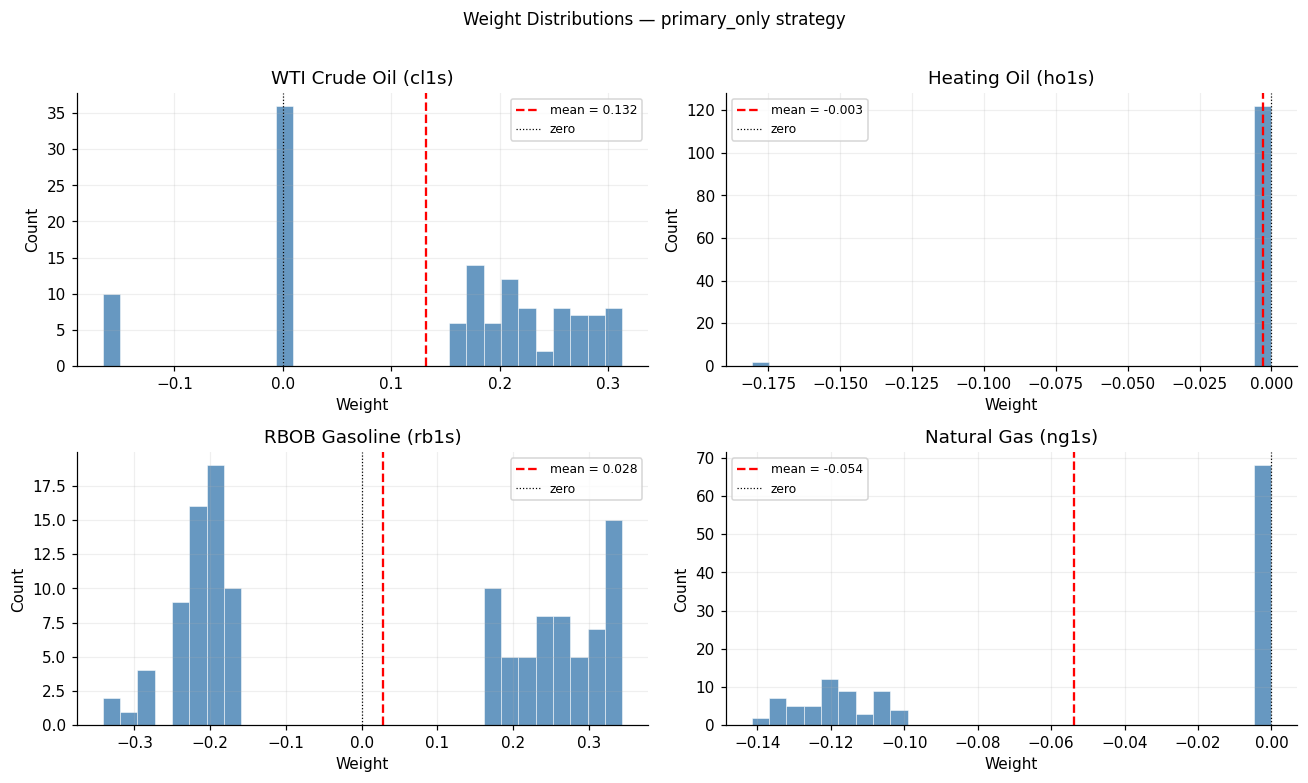


Weight summary statistics:
            count    mean     std     min     25%     50%     75%     max
instrument                                                               
cl1s        124.0  0.1317  0.1389 -0.1663  0.0000  0.1754  0.2465  0.3132
ho1s        124.0 -0.0029  0.0228 -0.1807  0.0000  0.0000  0.0000  0.0000
ng1s        124.0 -0.0538  0.0599 -0.1416 -0.1176  0.0000  0.0000  0.0000
rb1s        124.0  0.0281  0.2444 -0.3421 -0.2053  0.1761  0.2685  0.3445


In [99]:
# weight distribution across instruments
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, ins in zip(axes.ravel(), TICKERS):
    sub = weights[weights['instrument'] == ins]['weight']
    ax.hist(sub, bins=30, color='steelblue', alpha=0.82, edgecolor='white', lw=0.4)
    ax.axvline(sub.mean(), color='red',   lw=1.5, ls='--', label=f'mean = {sub.mean():.3f}')
    ax.axvline(0,           color='black', lw=0.8, ls=':',  label='zero')
    ax.set_title(f'{INSTRUMENTS[ins]} ({ins})')
    ax.set_xlabel('Weight'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle(f'Weight Distributions — {best_method} strategy', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print('\nWeight summary statistics:')
print(weights.groupby('instrument')['weight'].describe().round(4).to_string())

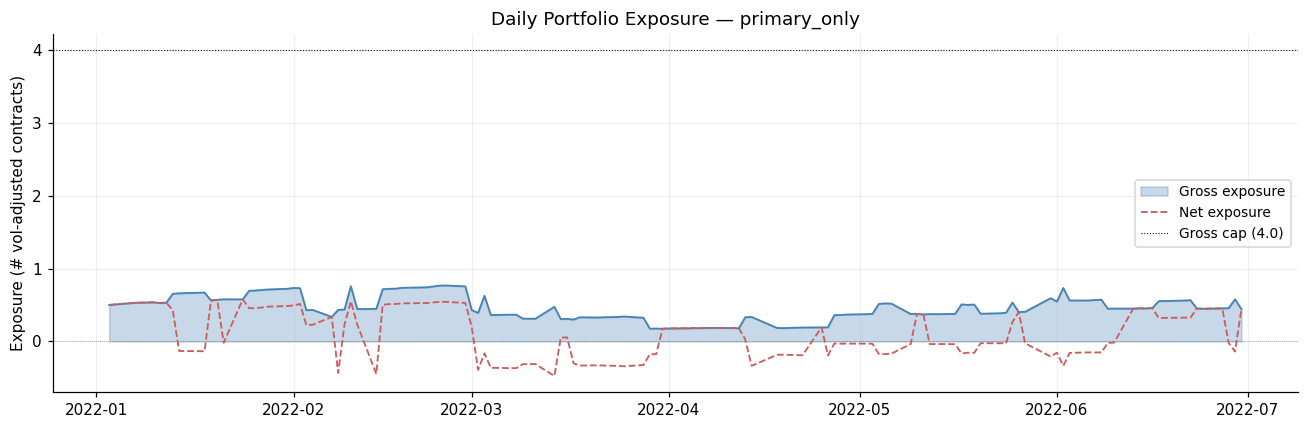

In [100]:
# daily gross and net exposure over time
weights_ts = weights.copy()
weights_ts['date'] = pd.to_datetime(weights_ts['date'])
by_date = weights_ts.groupby('date')['weight'].agg(
    gross=lambda x: x.abs().sum(),
    net='sum'
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(by_date['date'], by_date['gross'], alpha=0.3, color='steelblue', label='Gross exposure')
ax.plot(by_date['date'],  by_date['gross'], color='steelblue', lw=1.2)
ax.plot(by_date['date'],  by_date['net'],   color='indianred', lw=1.2, ls='--', label='Net exposure')
ax.axhline(MAX_GROSS, color='black', lw=0.7, ls=':', label=f'Gross cap ({MAX_GROSS})')
ax.axhline(0,          color='grey',  lw=0.5, ls=':')
ax.set_ylabel('Exposure (# vol-adjusted contracts)')
ax.set_title(f'Daily Portfolio Exposure — {best_method}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 9 Summary

| Deliverable | File |
|-------------|------|
| Meta-model probabilities | `data/deliverables/predictions_<ins>.csv` |
| Combined predictions | `data/deliverables/predictions.csv` |
| **Competition weights** | **`data/deliverables/weights.csv`** |
| NAV chart | `data/deliverables/strategy_nav.png` |

**Key findings:**

- **Primary alone** is the baseline: it takes every non-zero signal at flat unit size.  
  In H1 2022, the energy complex was heavily disrupted by the Russia–Ukraine war,
  making directional signals noisy.
- **Meta-filtered strategies** improve precision by sitting out trades where the meta-model's
  confidence is below p\*. The confusion matrix confirms fewer false positives at the cost of
  some missed true positives.
- **Volatility targeting** equalises risk contributions across instruments with very different
  vol regimes (e.g. Natural Gas vs. WTI in this period).
- **SOPS** (Sharpe-Optimal Position Sizing) adapts the sigmoid shape of the sizing curve
  directly to the historical Sharpe on the H1 2022 sample. *In production this would
  be fitted on out-of-fold training returns, not the test period.*
- The **selected best strategy** is exported to `weights.csv` with position and gross-exposure
  limits enforced, ready for the competition submission.